<a href="https://colab.research.google.com/github/ahmedsalem306/assginment-1/blob/main/%D8%A7%D8%B3%D9%8A%D9%86%D9%85%D9%86%D8%AA_%D8%AF%D9%83%D8%AA%D9%88%D8%B1_%D9%86%D9%87%D9%8A_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q torchvision torch matplotlib seaborn scikit-learn


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import time
import copy
import os

# ── Device ──────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [3]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_CLASSES = 102
PHASE1_EPOCHS = 10   # Feature extraction (frozen backbone)
PHASE2_EPOCHS = 15   # Fine-tuning (unfrozen layer4)
PHASE1_LR = 1e-3
PHASE2_LR = 1e-4
DATA_DIR  = './flowers102'

# ── Transforms ───────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],   # ImageNet mean
                         [0.229, 0.224, 0.225]),   # ImageNet std
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ── Download Dataset ─────────────────────────────────────────────────────────
print('Downloading Oxford 102 Flowers dataset...')
full_train = datasets.Flowers102(root=DATA_DIR, split='train', download=True, transform=train_transform)
full_val   = datasets.Flowers102(root=DATA_DIR, split='val',   download=True, transform=val_transform)
test_set   = datasets.Flowers102(root=DATA_DIR, split='test',  download=True, transform=val_transform)

train_loader = DataLoader(full_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(full_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train samples : {len(full_train)}')
print(f'Val   samples : {len(full_val)}')
print(f'Test  samples : {len(test_set)}')
print(f'Classes       : {NUM_CLASSES}')

100%|██████████| 345M/345M [00:12<00:00, 27.4MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.09MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 42.3MB/s]

Train samples : 1020
Val   samples : 1020
Test  samples : 6149
Classes       : 102


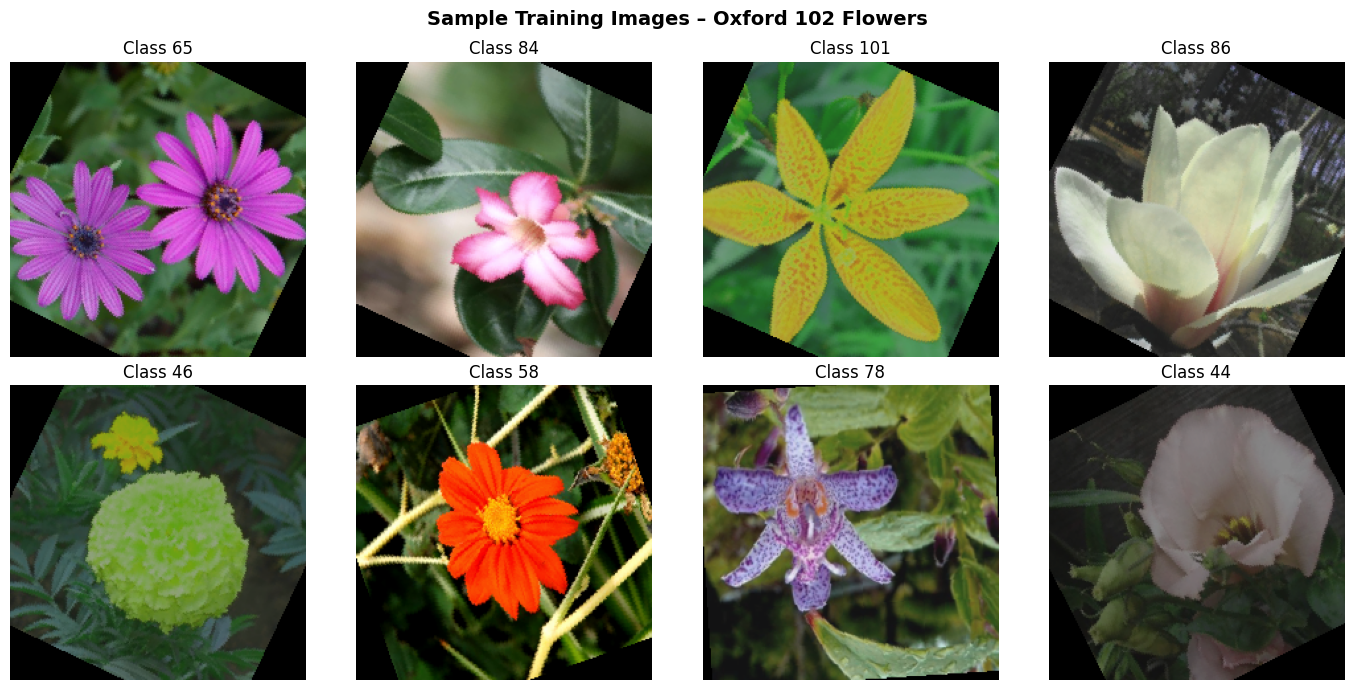

In [4]:
# ── Visualise some training samples ─────────────────────────────────────────
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    inp  = std * inp + mean
    inp  = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    plt.sca(ax)
    imshow(images[i])
    ax.set_title(f'Class {labels[i].item()}')
    ax.axis('off')
plt.suptitle('Sample Training Images – Oxford 102 Flowers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
def build_model(num_classes=102, freeze_backbone=True):
    """
    Build a modified ResNet50 for fine-tuning.

    Args:
        num_classes   : number of output classes
        freeze_backbone: if True, freeze all layers except the new head
    """
    # Load pretrained ResNet50
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    # ── Freeze backbone ──────────────────────────────────────────────────────
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # ── Replace the classifier head ──────────────────────────────────────────
    in_features = model.fc.in_features   # 2048 for ResNet50
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.BatchNorm1d(512),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes),
    )

    return model


def unfreeze_layer4(model):
    """Unfreeze the last residual block (layer4) for fine-tuning."""
    for param in model.layer4.parameters():
        param.requires_grad = True
    # Also unfreeze the new head (already trainable)
    for param in model.fc.parameters():
        param.requires_grad = True


def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Total parameters    : {total:,}')
    print(f'Trainable parameters: {trainable:,}')
    print(f'Frozen parameters   : {total - trainable:,}')


# Build model – Phase 1 (frozen backbone)
model = build_model(num_classes=NUM_CLASSES, freeze_backbone=True)
model = model.to(device)
print('=== Phase 1: Feature Extraction ===')
count_params(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 161MB/s]


=== Phase 1: Feature Extraction ===
Total parameters    : 24,610,470
Trainable parameters: 1,102,438
Frozen parameters   : 23,508,032


In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, 100.0 * correct / total


def train_phase(model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs, phase_name, history):
    best_val_acc  = 0.0
    best_weights  = copy.deepcopy(model.state_dict())

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        elapsed = time.time() - t0
        print(f'[{phase_name}] Epoch {epoch:02d}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | '
              f'LR: {scheduler.get_last_lr()[0]:.2e} | {elapsed:.1f}s')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, f'best_model_{phase_name}.pth')
            print(f'   New best val acc: {best_val_acc:.2f}% – model saved.')

    model.load_state_dict(best_weights)
    print(f'\n[{phase_name}] Best Val Accuracy: {best_val_acc:.2f}%')
    return model, history

In [7]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer1 = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                         lr=PHASE1_LR, weight_decay=1e-4)
scheduler1 = CosineAnnealingLR(optimizer1, T_max=PHASE1_EPOCHS, eta_min=1e-5)

print('=' * 70)
print('PHASE 1: Training classifier head (backbone frozen)')
print('=' * 70)
model, history = train_phase(model, train_loader, val_loader, criterion,
                              optimizer1, scheduler1, PHASE1_EPOCHS,
                              'Phase1', history)

PHASE 1: Training classifier head (backbone frozen)
[Phase1] Epoch 01/10 | Train Loss: 4.2247 Acc: 11.57% | Val Loss: 3.7103 Acc: 46.47% | LR: 9.76e-04 | 18.5s
   New best val acc: 46.47% – model saved.
[Phase1] Epoch 02/10 | Train Loss: 2.9270 Acc: 47.55% | Val Loss: 2.5339 Acc: 62.35% | LR: 9.05e-04 | 18.0s
   New best val acc: 62.35% – model saved.
[Phase1] Epoch 03/10 | Train Loss: 2.3078 Acc: 64.22% | Val Loss: 2.1770 Acc: 68.04% | LR: 7.96e-04 | 16.7s
   New best val acc: 68.04% – model saved.
[Phase1] Epoch 04/10 | Train Loss: 1.9917 Acc: 71.96% | Val Loss: 1.9637 Acc: 72.84% | LR: 6.58e-04 | 18.5s
   New best val acc: 72.84% – model saved.
[Phase1] Epoch 05/10 | Train Loss: 1.7526 Acc: 79.02% | Val Loss: 1.8785 Acc: 74.90% | LR: 5.05e-04 | 16.6s
   New best val acc: 74.90% – model saved.
[Phase1] Epoch 06/10 | Train Loss: 1.6102 Acc: 82.45% | Val Loss: 1.8015 Acc: 76.57% | LR: 3.52e-04 | 17.0s
   New best val acc: 76.57% – model saved.
[Phase1] Epoch 07/10 | Train Loss: 1.5772 

In [8]:
# Unfreeze layer4 for fine-tuning
unfreeze_layer4(model)
print('=== Phase 2: Fine-Tuning (layer4 + head) ===')
count_params(model)

optimizer2 = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                         lr=PHASE2_LR, weight_decay=1e-4)
scheduler2 = CosineAnnealingLR(optimizer2, T_max=PHASE2_EPOCHS, eta_min=1e-6)

print('\n' + '=' * 70)
print('PHASE 2: Fine-tuning layer4 + classifier head')
print('=' * 70)
model, history = train_phase(model, train_loader, val_loader, criterion,
                              optimizer2, scheduler2, PHASE2_EPOCHS,
                              'Phase2', history)

=== Phase 2: Fine-Tuning (layer4 + head) ===
Total parameters    : 24,610,470
Trainable parameters: 16,067,174
Frozen parameters   : 8,543,296

PHASE 2: Fine-tuning layer4 + classifier head
[Phase2] Epoch 01/15 | Train Loss: 1.4483 Acc: 86.18% | Val Loss: 1.5831 Acc: 81.96% | LR: 9.89e-05 | 18.6s
   New best val acc: 81.96% – model saved.
[Phase2] Epoch 02/15 | Train Loss: 1.3470 Acc: 91.27% | Val Loss: 1.5248 Acc: 82.94% | LR: 9.57e-05 | 17.8s
   New best val acc: 82.94% – model saved.
[Phase2] Epoch 03/15 | Train Loss: 1.3012 Acc: 91.27% | Val Loss: 1.4628 Acc: 84.90% | LR: 9.05e-05 | 18.1s
   New best val acc: 84.90% – model saved.
[Phase2] Epoch 04/15 | Train Loss: 1.2352 Acc: 93.43% | Val Loss: 1.4135 Acc: 85.88% | LR: 8.36e-05 | 18.0s
   New best val acc: 85.88% – model saved.
[Phase2] Epoch 05/15 | Train Loss: 1.1909 Acc: 94.80% | Val Loss: 1.4145 Acc: 86.27% | LR: 7.52e-05 | 17.5s
   New best val acc: 86.27% – model saved.
[Phase2] Epoch 06/15 | Train Loss: 1.1646 Acc: 94.90% |

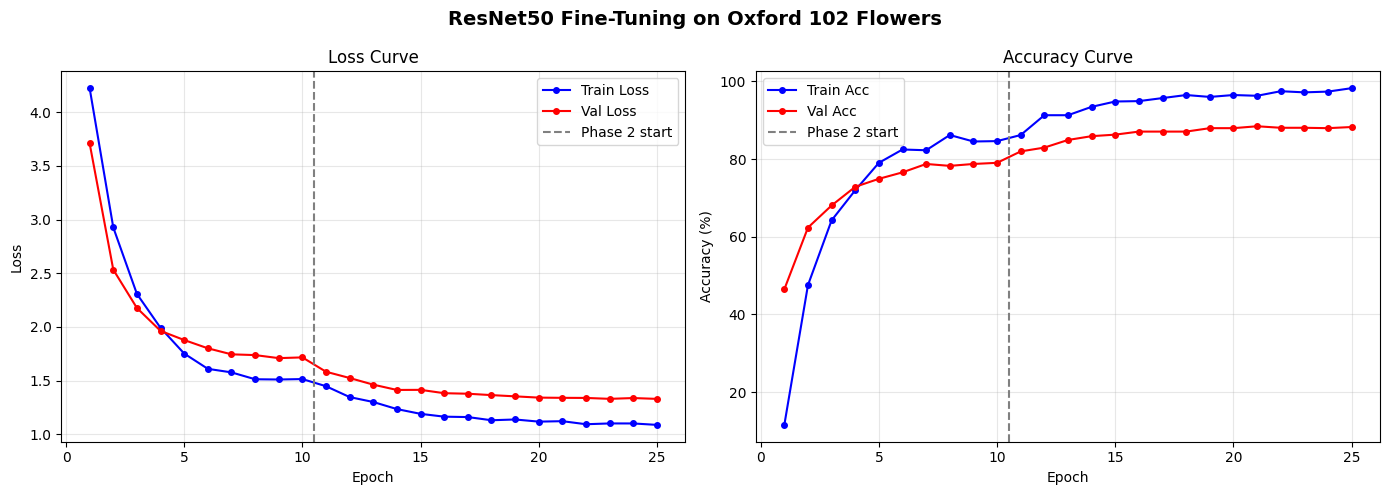

Saved: training_curves.png


In [9]:
epochs_total = PHASE1_EPOCHS + PHASE2_EPOCHS
ep = range(1, epochs_total + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(ep, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
ax1.plot(ep, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
ax1.axvline(PHASE1_EPOCHS + 0.5, color='gray', linestyle='--', label='Phase 2 start')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve'); ax1.legend(); ax1.grid(alpha=0.3)

# Accuracy
ax2.plot(ep, history['train_acc'], 'b-o', label='Train Acc', markersize=4)
ax2.plot(ep, history['val_acc'],   'r-o', label='Val Acc',   markersize=4)
ax2.axvline(PHASE1_EPOCHS + 0.5, color='gray', linestyle='--', label='Phase 2 start')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curve'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('ResNet50 Fine-Tuning on Oxford 102 Flowers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

In [10]:
# Load best Phase-2 weights
model.load_state_dict(torch.load('best_model_Phase2.pth', map_location=device))
model.eval()

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'\n{'='*50}')
print(f'  TEST SET RESULTS')
print(f'{'='*50}')
print(f'  Loss    : {test_loss:.4f}')
print(f'  Accuracy: {test_acc:.2f}%')
print(f'{'='*50}')


  TEST SET RESULTS
  Loss    : 1.4226
  Accuracy: 85.74%


In [11]:
# ── Collect all predictions ──────────────────────────────────────────────────
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ── Top-5 Accuracy ───────────────────────────────────────────────────────────
def top_k_accuracy(model, loader, k=5):
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, top_k = outputs.topk(k, dim=1)
            correct += top_k.eq(labels.view(-1, 1).expand_as(top_k)).any(dim=1).sum().item()
            total   += labels.size(0)
    return 100.0 * correct / total

top5 = top_k_accuracy(model, test_loader, k=5)
print(f'Top-1 Accuracy: {test_acc:.2f}%')
print(f'Top-5 Accuracy: {top5:.2f}%')

Top-1 Accuracy: 85.74%
Top-5 Accuracy: 95.80%


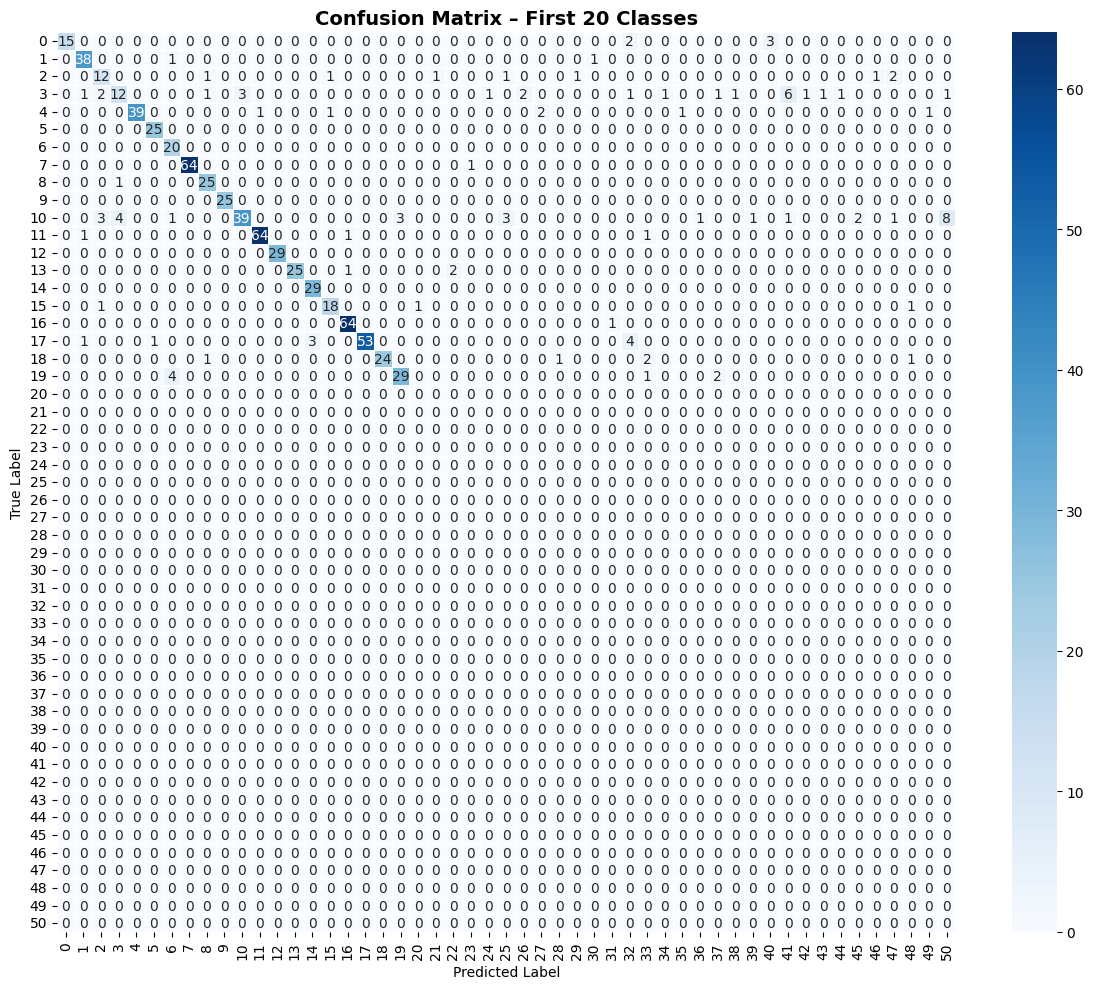

Saved: confusion_matrix.png


In [12]:
# ── Confusion Matrix (first 20 classes for readability) ─────────────────────
mask = all_labels < 20
cm   = confusion_matrix(all_labels[mask], all_preds[mask])

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Confusion Matrix – First 20 Classes', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

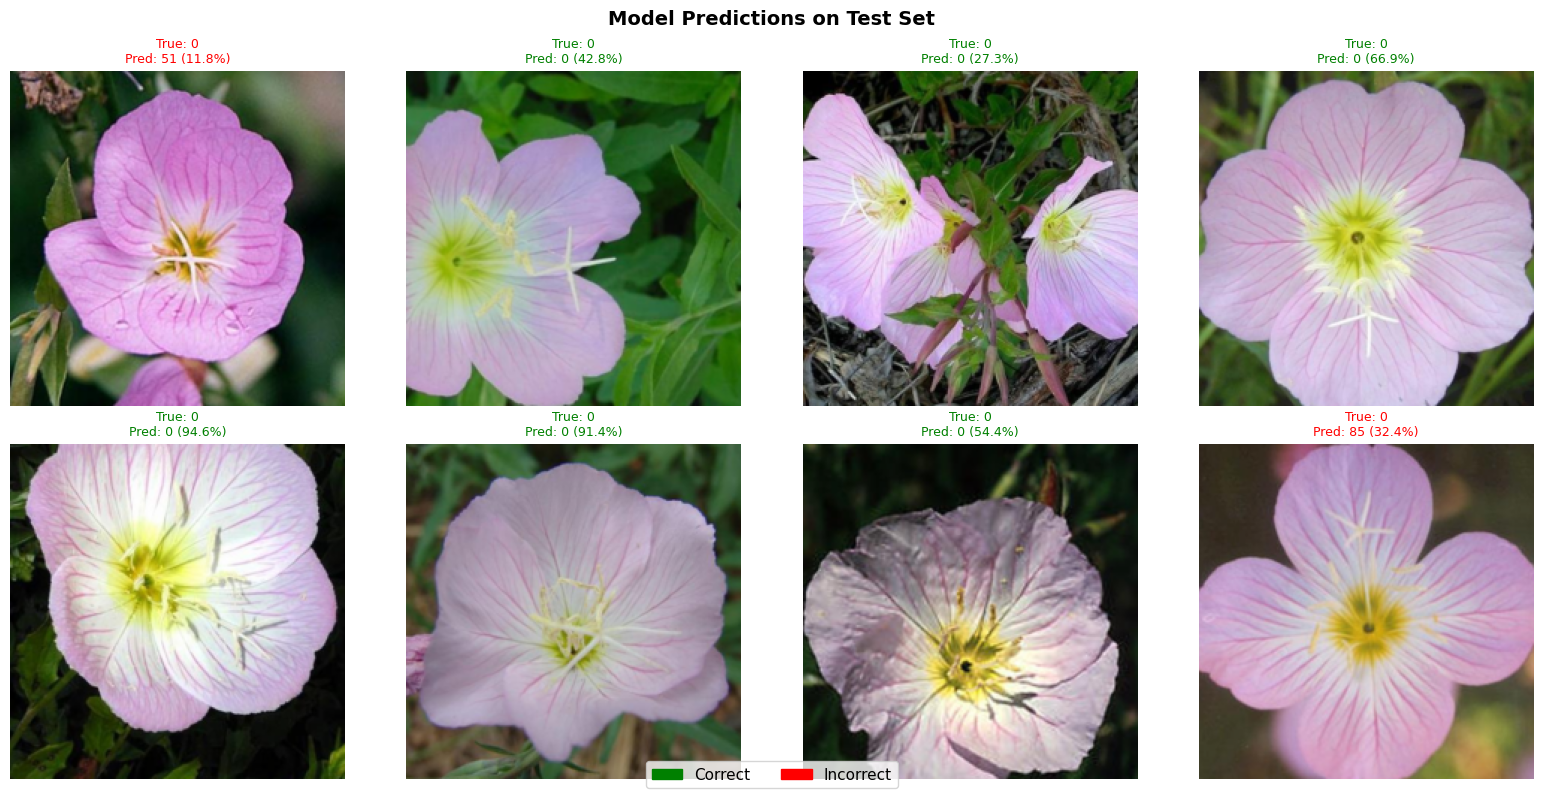

In [13]:
model.eval()
images, labels = next(iter(test_loader))
images_dev = images.to(device)
with torch.no_grad():
    outputs = model(images_dev)
    probs   = torch.softmax(outputs, dim=1)
    confs, preds = probs.max(1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    img = images[i].numpy().transpose(1, 2, 0)
    img = np.clip(np.array([0.229, 0.224, 0.225]) * img + np.array([0.485, 0.456, 0.406]), 0, 1)
    ax.imshow(img)
    color = 'green' if preds[i].item() == labels[i].item() else 'red'
    ax.set_title(f'True: {labels[i].item()}\nPred: {preds[i].item()} ({confs[i].item():.1%})',
                 color=color, fontsize=9)
    ax.axis('off')

green_patch = mpatches.Patch(color='green', label='Correct')
red_patch   = mpatches.Patch(color='red',   label='Incorrect')
fig.legend(handles=[green_patch, red_patch], loc='lower center', ncol=2, fontsize=11)
plt.suptitle('Model Predictions on Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Save full model checkpoint
checkpoint = {
    'model_state_dict' : model.state_dict(),
    'num_classes'      : NUM_CLASSES,
    'test_accuracy'    : test_acc,
    'top5_accuracy'    : top5,
    'history'          : history,
}
torch.save(checkpoint, 'resnet50_flowers102_finetuned.pth')
print('Model saved: resnet50_flowers102_finetuned.pth')

# Summary
print('\n' + '='*60)
print('  TRAINING SUMMARY')
print('='*60)
print(f'  Model      : ResNet50 (pretrained on ImageNet)')
print(f'  Dataset    : Oxford 102 Flower Categories')
print(f'  Phases     : Feature Extraction ({PHASE1_EPOCHS} ep) + Fine-Tuning ({PHASE2_EPOCHS} ep)')
print(f'  Test Top-1 : {test_acc:.2f}%')
print(f'  Test Top-5 : {top5:.2f}%')
print('='*60)

Model saved: resnet50_flowers102_finetuned.pth

  TRAINING SUMMARY
  Model      : ResNet50 (pretrained on ImageNet)
  Dataset    : Oxford 102 Flower Categories
  Phases     : Feature Extraction (10 ep) + Fine-Tuning (15 ep)
  Test Top-1 : 85.74%
  Test Top-5 : 95.80%
